# 効率的フロンティアの数理とPython実装
## マーコウィッツの平均分散モデルを理論から導出する

このノートブックは、Zenn記事「効率的フロンティアの数理とPython実装」の実装コードです。
記事本文と対応させながら、コードを上から順に実行してください。

### データ
- 銘柄: AAPL, MSFT, AMZN, JPM, JNJ
- 期間: 2000-01-01 ~ 2025-12-31
- ベンチマーク: S&P 500 (^GSPC)

## 0. 環境セットアップ

In [1]:
!pip install yfinance -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

## 1. 株式リターンの基礎

### データ取得

In [3]:
# 銘柄とベンチマーク
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
benchmark = '^GSPC'

# 株価データ取得（終値）
data = yf.download(tickers, start='2000-01-01', end='2025-12-31')['Close']
sp500 = yf.download(benchmark, start='2000-01-01', end='2025-12-31')['Close']

print(f"データ期間: {data.index[0].strftime('%Y-%m-%d')} ~ {data.index[-1].strftime('%Y-%m-%d')}")
print(f"データ件数: {len(data)}")
print()
data.head()

/tmp/ipykernel_4164/4258896197.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2000-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_4164/4258896197.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(benchmark, start='2000-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  1 of 1 completed

データ期間: 2000-01-03 ~ 2025-12-30
データ件数: 6538



Ticker,AAPL,AMZN,JNJ,JPM,MSFT
Date,,,,,
2000-01-03,0.838496,4.468750,23.282217,22.793856,35.520382
2000-01-04,0.767803,4.096875,22.429840,22.293720,34.320488
2000-01-05,0.779038,3.487500,22.666616,22.156096,34.682354
2000-01-06,0.711621,3.278125,23.376928,22.470652,33.520569
2000-01-07,0.745330,3.478125,24.371349,22.883480,33.958626


### 対数リターンと単純リターンの計算

**対数リターン**: $r_t = \ln\frac{P_t}{P_{t-1}}$

**単純リターン**: $R_t = \frac{P_t}{P_{t-1}} - 1$

In [4]:
# 日次対数リターン
log_returns = np.log(data / data.shift(1)).dropna()

# 日次単純リターン
simple_returns = data.pct_change().dropna()

# 年率リターンと年率ボラティリティ
annual_return = log_returns.mean() * 252
annual_vol = log_returns.std() * np.sqrt(252)

print("=== 年率リターン (annualized log return) ===")
print(annual_return.round(4))
print()
print("=== 年率ボラティリティ (annualized volatility) ===")
print(annual_vol.round(4))

=== 年率リターン (annualized log return) ===
Ticker
AAPL    0.2230
AMZN    0.1523
JNJ     0.0840
JPM     0.1019
MSFT    0.1009
dtype: float64

=== 年率ボラティリティ (annualized volatility) ===
Ticker
AAPL    0.3981
AMZN    0.4832
JNJ     0.1917
JPM     0.3678
MSFT    0.3000
dtype: float64


### 図1: 累積リターンの推移（2000-2025）

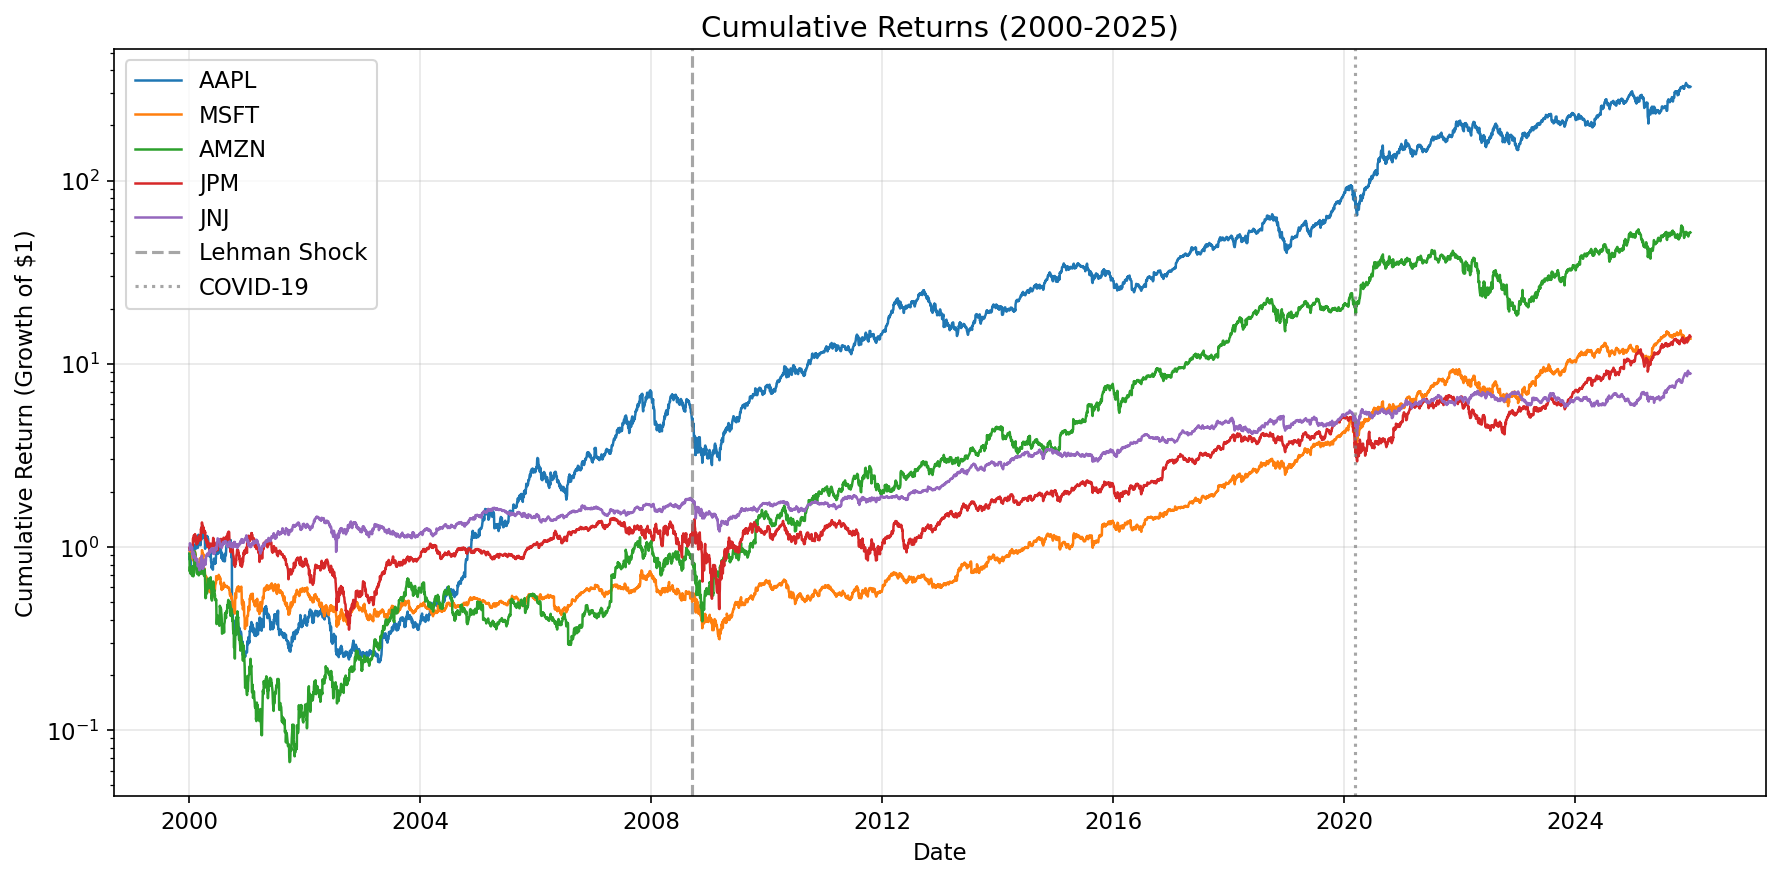

In [5]:
# 累積リターン
cumulative = (1 + simple_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in tickers:
    ax.plot(cumulative.index, cumulative[ticker], label=ticker, linewidth=1.2)

# リーマンショック・コロナショック
ax.axvline(pd.Timestamp('2008-09-15'), color='gray', linestyle='--', alpha=0.7, label='Lehman Shock')
ax.axvline(pd.Timestamp('2020-03-11'), color='gray', linestyle=':', alpha=0.7, label='COVID-19')

ax.set_title('Cumulative Returns (2000-2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Growth of $1)')
ax.legend(loc='upper left')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. リスクの定量化

**分散**: $\sigma^2 = \frac{1}{T-1}\sum_{t=1}^{T}(r_t - \bar{r})^2$

**ボラティリティ**: $\sigma = \sqrt{\sigma^2}$

### 図2: リターン分布（ヒストグラム + 正規分布フィット）

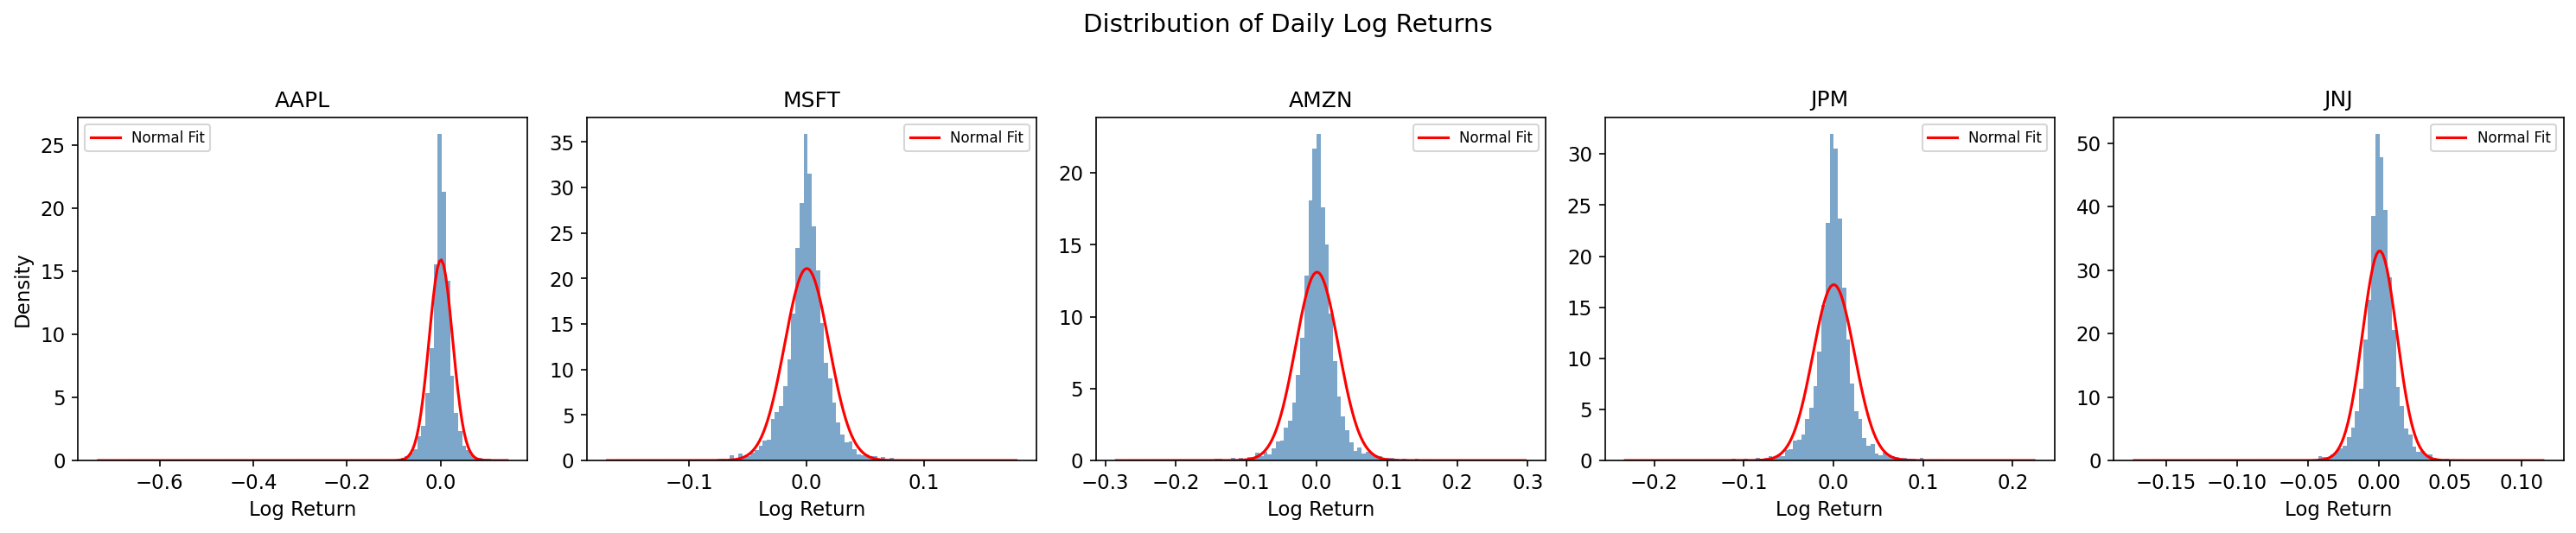

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ticker in enumerate(tickers):
    ax = axes[i]
    returns_data = log_returns[ticker].dropna()

    # ヒストグラム
    ax.hist(returns_data, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='none')

    # 正規分布フィット
    mu_fit = returns_data.mean()
    sigma_fit = returns_data.std()
    x = np.linspace(returns_data.min(), returns_data.max(), 200)
    pdf = (1 / (sigma_fit * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu_fit) / sigma_fit) ** 2)
    ax.plot(x, pdf, 'r-', linewidth=1.5, label='Normal Fit')

    ax.set_title(ticker, fontsize=12)
    ax.set_xlabel('Log Return')
    if i == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Daily Log Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 図3: 基本統計量テーブル

正規分布の場合、歪度(Skewness)=0、超過尖度(Excess Kurtosis)=0 となります。

        Annual Return  Annual Volatility  Skewness  Excess Kurtosis
Ticker                                                             
AAPL           0.2230             0.3981   -3.9267         114.5961
AMZN           0.1523             0.4832    0.4205          13.0409
JNJ            0.0840             0.1917   -0.4685          13.9815
JPM            0.1019             0.3678    0.2130          14.6684
MSFT           0.1009             0.3000   -0.1381           9.3773


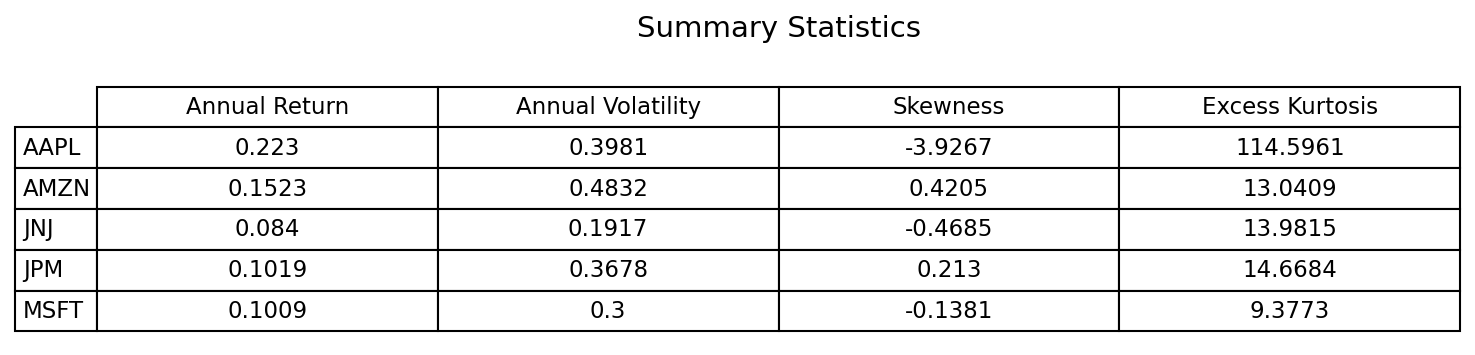

In [7]:
stats_df = pd.DataFrame({
    'Annual Return': log_returns.mean() * 252,
    'Annual Volatility': log_returns.std() * np.sqrt(252),
    'Skewness': log_returns.apply(skew),
    'Excess Kurtosis': log_returns.apply(kurtosis)
})

# テーブルとして表示
print(stats_df.round(4).to_string())

# matplotlibテーブルとして描画
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
table = ax.table(
    cellText=stats_df.round(4).values,
    colLabels=stats_df.columns,
    rowLabels=stats_df.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax.set_title('Summary Statistics', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 3. 共分散と相関係数

**共分散**: $\text{Cov}(r_i, r_j) = \frac{1}{T-1}\sum_{t=1}^{T}(r_{i,t} - \bar{r}_i)(r_{j,t} - \bar{r}_j)$

**相関係数**: $\rho_{ij} = \frac{\text{Cov}(r_i, r_j)}{\sigma_i \sigma_j}$

### 図4: 相関行列ヒートマップ

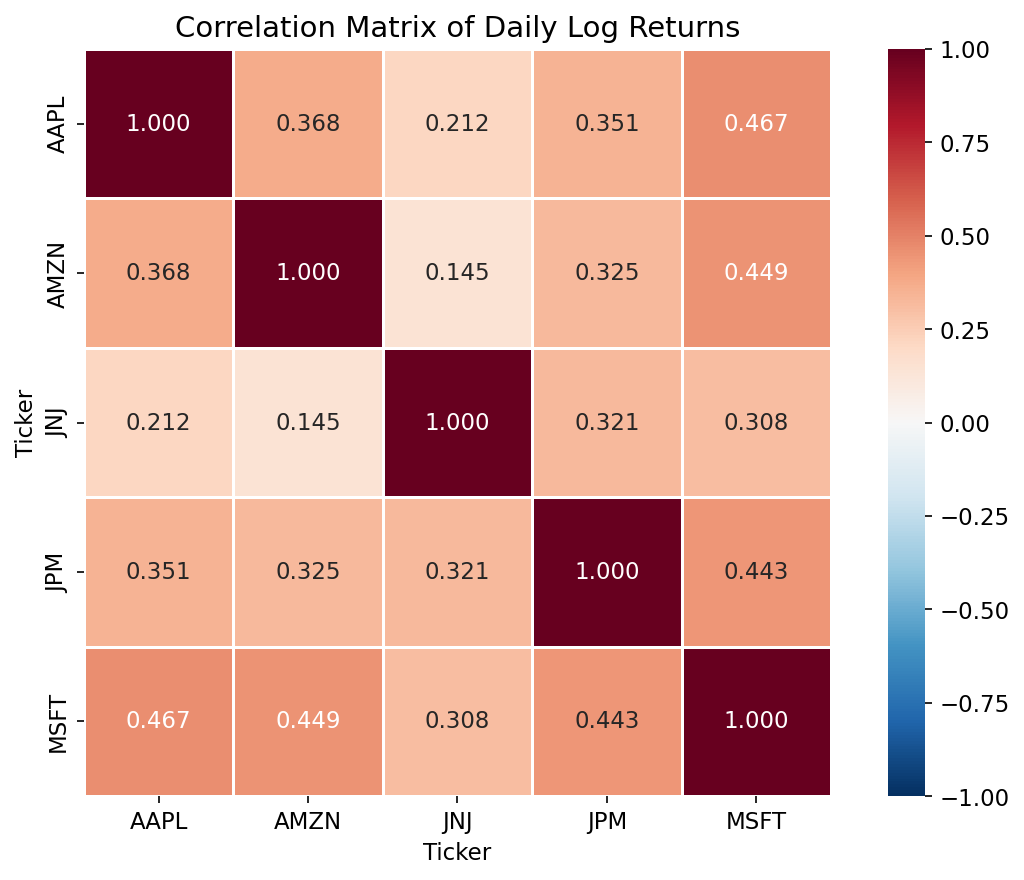

In [8]:
# 共分散行列（年率換算）
cov_matrix = log_returns.cov() * 252

# 相関行列
corr_matrix = log_returns.corr()

# ヒートマップ
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Correlation Matrix of Daily Log Returns', fontsize=14)
plt.tight_layout()
plt.show()

### 図5: 2銘柄のリターン散布図（AAPL vs JPM）

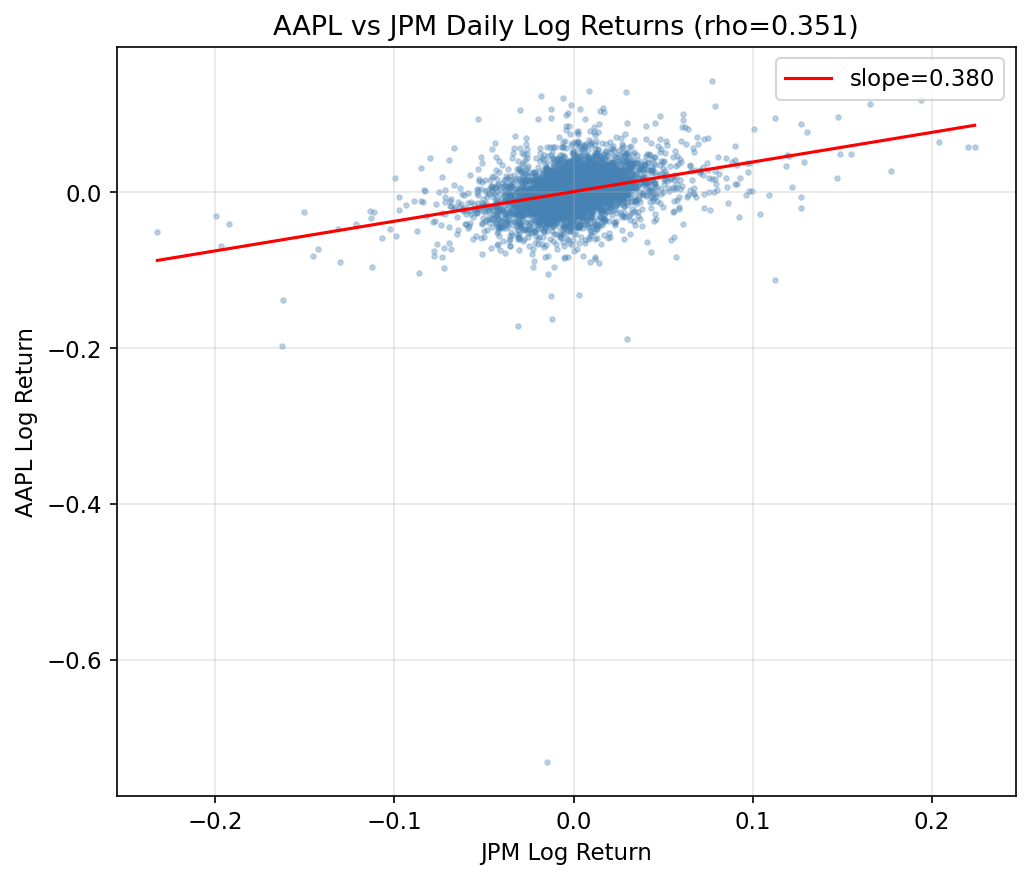

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(log_returns['JPM'], log_returns['AAPL'], alpha=0.3, s=5, color='steelblue')

# 回帰直線
z = np.polyfit(log_returns['JPM'].values, log_returns['AAPL'].values, 1)
p = np.poly1d(z)
x_line = np.linspace(log_returns['JPM'].min(), log_returns['JPM'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=1.5, label=f'slope={z[0]:.3f}')

rho = corr_matrix.loc['AAPL', 'JPM']
ax.set_title(f'AAPL vs JPM Daily Log Returns (rho={rho:.3f})', fontsize=13)
ax.set_xlabel('JPM Log Return')
ax.set_ylabel('AAPL Log Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. ポートフォリオのリターンとリスク

**ポートフォリオリターン**: $E[R_p] = \mathbf{w}^T \boldsymbol{\mu}$

**ポートフォリオリスク**: $\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$

### ランダムポートフォリオの生成

In [10]:
np.random.seed(42)
n_portfolios = 10000
n_assets = len(tickers)

# 年率パラメータ
mu = log_returns.mean().values * 252
cov = log_returns.cov().values * 252

# リスクフリーレート
rf = 0.02

# ランダムポートフォリオの生成
results = np.zeros((n_portfolios, 3))
weights_record = np.zeros((n_portfolios, n_assets))

for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    weights_record[i] = w

    port_return = w @ mu
    port_vol = np.sqrt(w @ cov @ w)
    sharpe = (port_return - rf) / port_vol

    results[i] = [port_return, port_vol, sharpe]

results_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Sharpe'])
print(f"Generated {n_portfolios} random portfolios")
print(f"Return range: [{results_df['Return'].min():.4f}, {results_df['Return'].max():.4f}]")
print(f"Volatility range: [{results_df['Volatility'].min():.4f}, {results_df['Volatility'].max():.4f}]")

Generated 10000 random portfolios
Return range: [0.0876, 0.2126]
Volatility range: [0.1787, 0.4508]


### 図6: ランダムポートフォリオ（リスク-リターン空間）

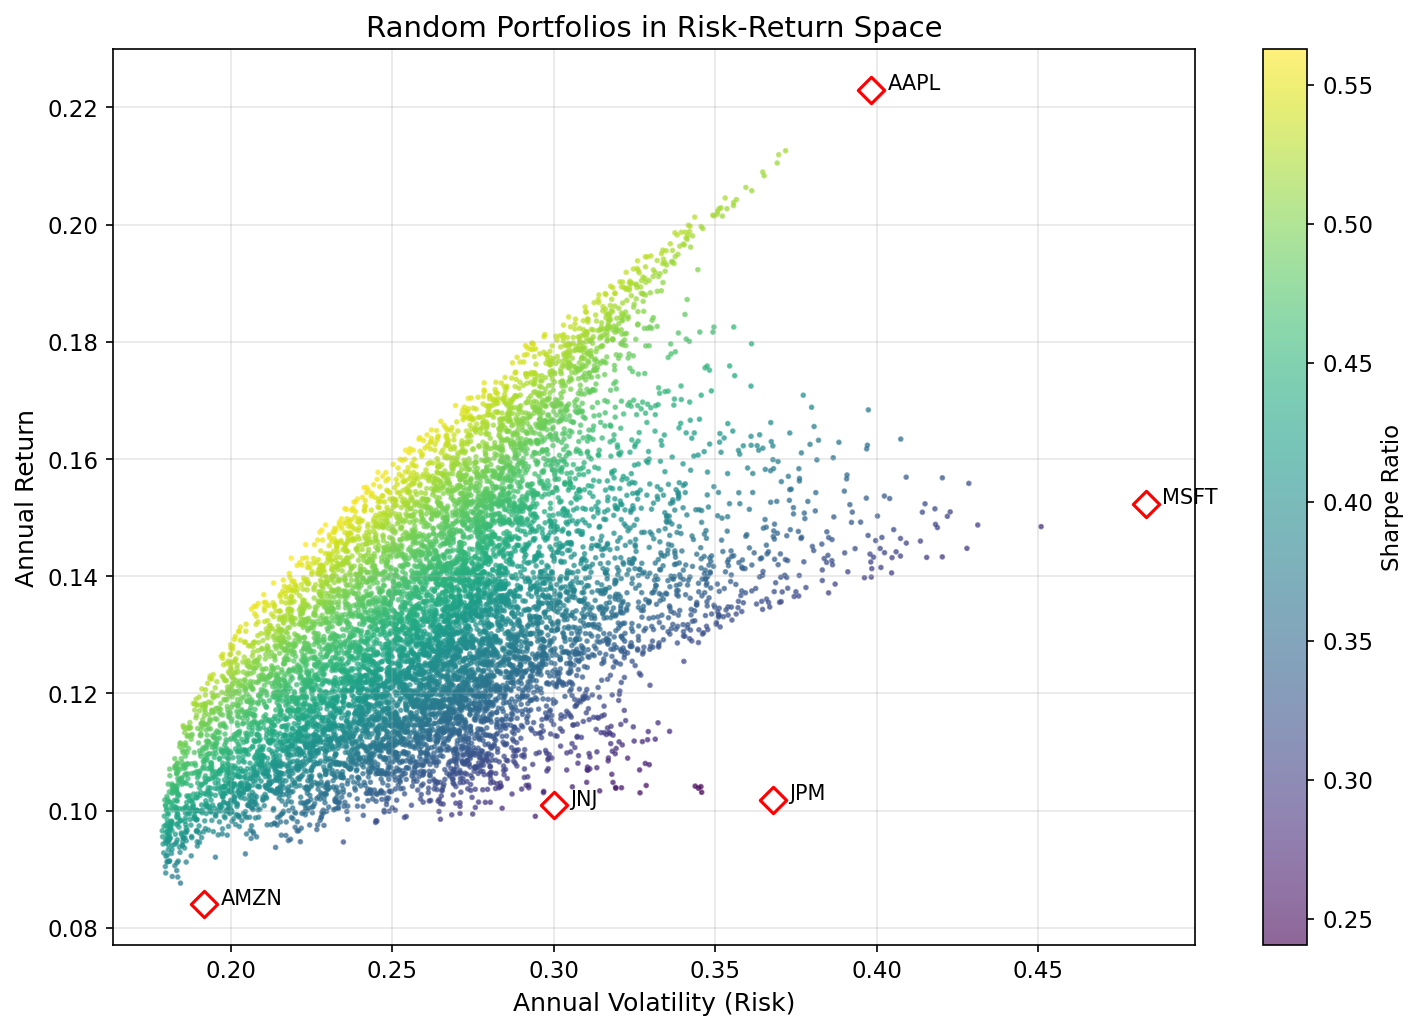

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(results_df['Volatility'], results_df['Return'],
                     c=results_df['Sharpe'], cmap='viridis', s=3, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# 個別銘柄のプロット
for i, ticker in enumerate(tickers):
    ax.scatter(np.sqrt(cov[i, i]), mu[i], marker='D', s=80,
               edgecolors='red', facecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(ticker, (np.sqrt(cov[i, i]), mu[i]),
                textcoords="offset points", xytext=(8, 0), fontsize=10)

ax.set_title('Random Portfolios in Risk-Return Space', fontsize=14)
ax.set_xlabel('Annual Volatility (Risk)', fontsize=12)
ax.set_ylabel('Annual Return', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. マーコウィッツの平均分散モデル

**最適化問題**:

$$\min_{\mathbf{w}} \quad \mathbf{w}^T \Sigma \mathbf{w}$$

$$\text{s.t.} \quad \mathbf{w}^T \boldsymbol{\mu} = \mu_{\text{target}}, \quad \mathbf{w}^T \mathbf{1} = 1, \quad w_i \geq 0$$

### 最適化関数の定義

In [12]:
def portfolio_performance(weights, mu, cov):
    """ポートフォリオのリターンとボラティリティを計算"""
    port_return = weights @ mu
    port_vol = np.sqrt(weights @ cov @ weights)
    return port_return, port_vol


def minimize_volatility(target_return, mu, cov, n_assets):
    """与えられたターゲットリターンのもとで分散を最小化"""
    constraints = [
        {'type': 'eq', 'fun': lambda w: w @ mu - target_return},
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    ]
    bounds = tuple((0, 1) for _ in range(n_assets))
    init_weights = np.ones(n_assets) / n_assets

    result = minimize(
        fun=lambda w: w @ cov @ w,
        x0=init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result


def maximize_sharpe(mu, cov, rf, n_assets):
    """シャープレシオを最大化（接線ポートフォリオ）"""
    def neg_sharpe(w):
        ret, vol = portfolio_performance(w, mu, cov)
        return -(ret - rf) / vol

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = tuple((0, 1) for _ in range(n_assets))
    init_weights = np.ones(n_assets) / n_assets

    result = minimize(
        fun=neg_sharpe,
        x0=init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    return result


print("Functions defined successfully.")

Functions defined successfully.


### 最小分散ポートフォリオと接線ポートフォリオの計算

In [13]:
# 最小分散ポートフォリオ (GMVP)
gmvp_result = minimize(
    fun=lambda w: w @ cov @ w,
    x0=np.ones(n_assets) / n_assets,
    method='SLSQP',
    bounds=tuple((0, 1) for _ in range(n_assets)),
    constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
)
gmvp_weights = gmvp_result.x
gmvp_ret, gmvp_vol = portfolio_performance(gmvp_weights, mu, cov)

# 接線ポートフォリオ (Tangency Portfolio)
tangency_result = maximize_sharpe(mu, cov, rf, n_assets)
tangency_weights = tangency_result.x
tangency_ret, tangency_vol = portfolio_performance(tangency_weights, mu, cov)
tangency_sharpe = (tangency_ret - rf) / tangency_vol

print("=== Global Minimum Variance Portfolio ===")
print(f"Return: {gmvp_ret:.4f}")
print(f"Volatility: {gmvp_vol:.4f}")
print(f"Sharpe Ratio: {(gmvp_ret - rf) / gmvp_vol:.4f}")
print(f"Weights:")
for t, w in zip(tickers, gmvp_weights):
    print(f"  {t}: {w:.4f}")

print()
print("=== Tangency Portfolio (Max Sharpe Ratio) ===")
print(f"Return: {tangency_ret:.4f}")
print(f"Volatility: {tangency_vol:.4f}")
print(f"Sharpe Ratio: {tangency_sharpe:.4f}")
print(f"Weights:")
for t, w in zip(tickers, tangency_weights):
    print(f"  {t}: {w:.4f}")

=== Global Minimum Variance Portfolio ===
Return: 0.0965
Volatility: 0.1787
Sharpe Ratio: 0.4279
Weights:
  AAPL: 0.0538
  MSFT: 0.0321
  AMZN: 0.7513
  JPM: 0.0273
  JNJ: 0.1356

=== Tangency Portfolio (Max Sharpe Ratio) ===
Return: 0.1500
Volatility: 0.2301
Sharpe Ratio: 0.5650
Weights:
  AAPL: 0.4409
  MSFT: 0.0690
  AMZN: 0.4901
  JPM: 0.0000
  JNJ: 0.0000


### 効率的フロンティアの計算

In [14]:
# ターゲットリターンの範囲
target_returns = np.linspace(gmvp_ret, mu.max(), 100)
efficient_vols = []
efficient_weights_list = []

for target in target_returns:
    res = minimize_volatility(target, mu, cov, n_assets)
    if res.success:
        _, vol = portfolio_performance(res.x, mu, cov)
        efficient_vols.append(vol)
        efficient_weights_list.append(res.x)
    else:
        efficient_vols.append(np.nan)
        efficient_weights_list.append(np.full(n_assets, np.nan))

efficient_vols = np.array(efficient_vols)

print(f"Efficient frontier computed: {np.sum(~np.isnan(efficient_vols))}/{len(target_returns)} points")

Efficient frontier computed: 100/100 points


### 図7: 効率的フロンティア（メインビジュアル）

赤い曲線が効率的フロンティア、黒い破線が資本市場線(CML)です。

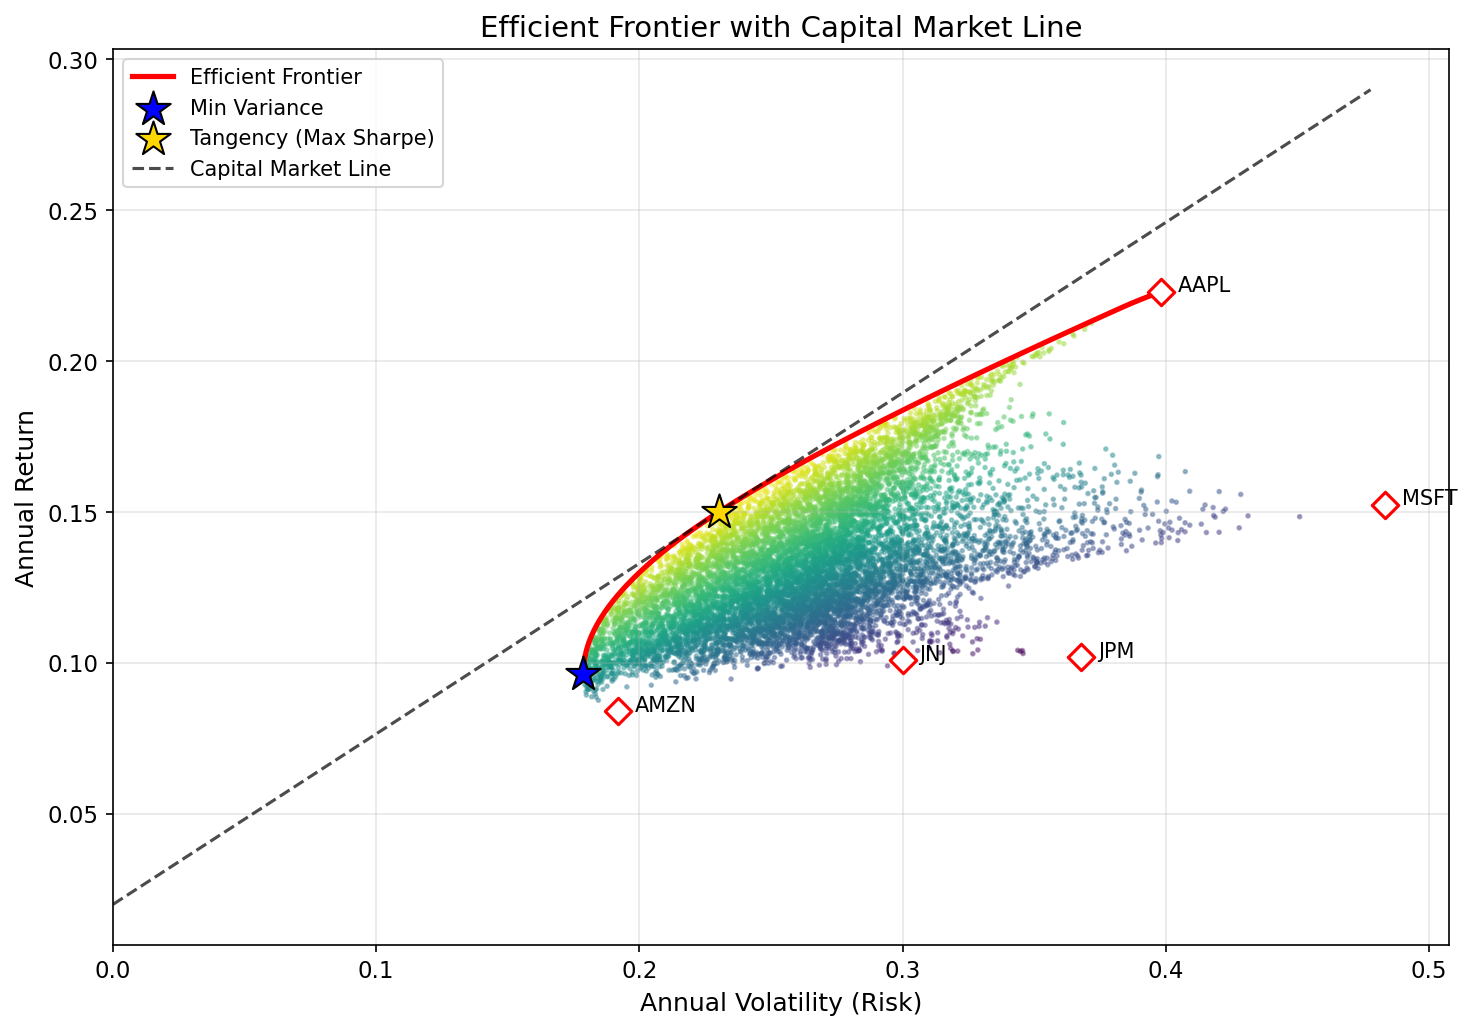

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))

# ランダムポートフォリオ
ax.scatter(results_df['Volatility'], results_df['Return'],
           c=results_df['Sharpe'], cmap='viridis', s=3, alpha=0.4)

# 効率的フロンティア
ax.plot(efficient_vols, target_returns, 'r-', linewidth=2.5, label='Efficient Frontier')

# 最小分散ポートフォリオ
ax.scatter(gmvp_vol, gmvp_ret, marker='*', s=300, c='blue',
           edgecolors='black', linewidths=1, zorder=5, label='Min Variance')

# 接線ポートフォリオ
ax.scatter(tangency_vol, tangency_ret, marker='*', s=300, c='gold',
           edgecolors='black', linewidths=1, zorder=5, label='Tangency (Max Sharpe)')

# 資本市場線 (CML)
cml_x = np.linspace(0, efficient_vols[~np.isnan(efficient_vols)].max() * 1.2, 100)
cml_y = rf + tangency_sharpe * cml_x
ax.plot(cml_x, cml_y, 'k--', linewidth=1.5, alpha=0.7, label='Capital Market Line')

# 個別銘柄
for i, ticker in enumerate(tickers):
    ax.scatter(np.sqrt(cov[i, i]), mu[i], marker='D', s=80,
               edgecolors='red', facecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(ticker, (np.sqrt(cov[i, i]), mu[i]),
                textcoords="offset points", xytext=(8, 0), fontsize=10)

ax.set_title('Efficient Frontier with Capital Market Line', fontsize=14)
ax.set_xlabel('Annual Volatility (Risk)', fontsize=12)
ax.set_ylabel('Annual Return', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

### 図8・図9: ポートフォリオの重み構成

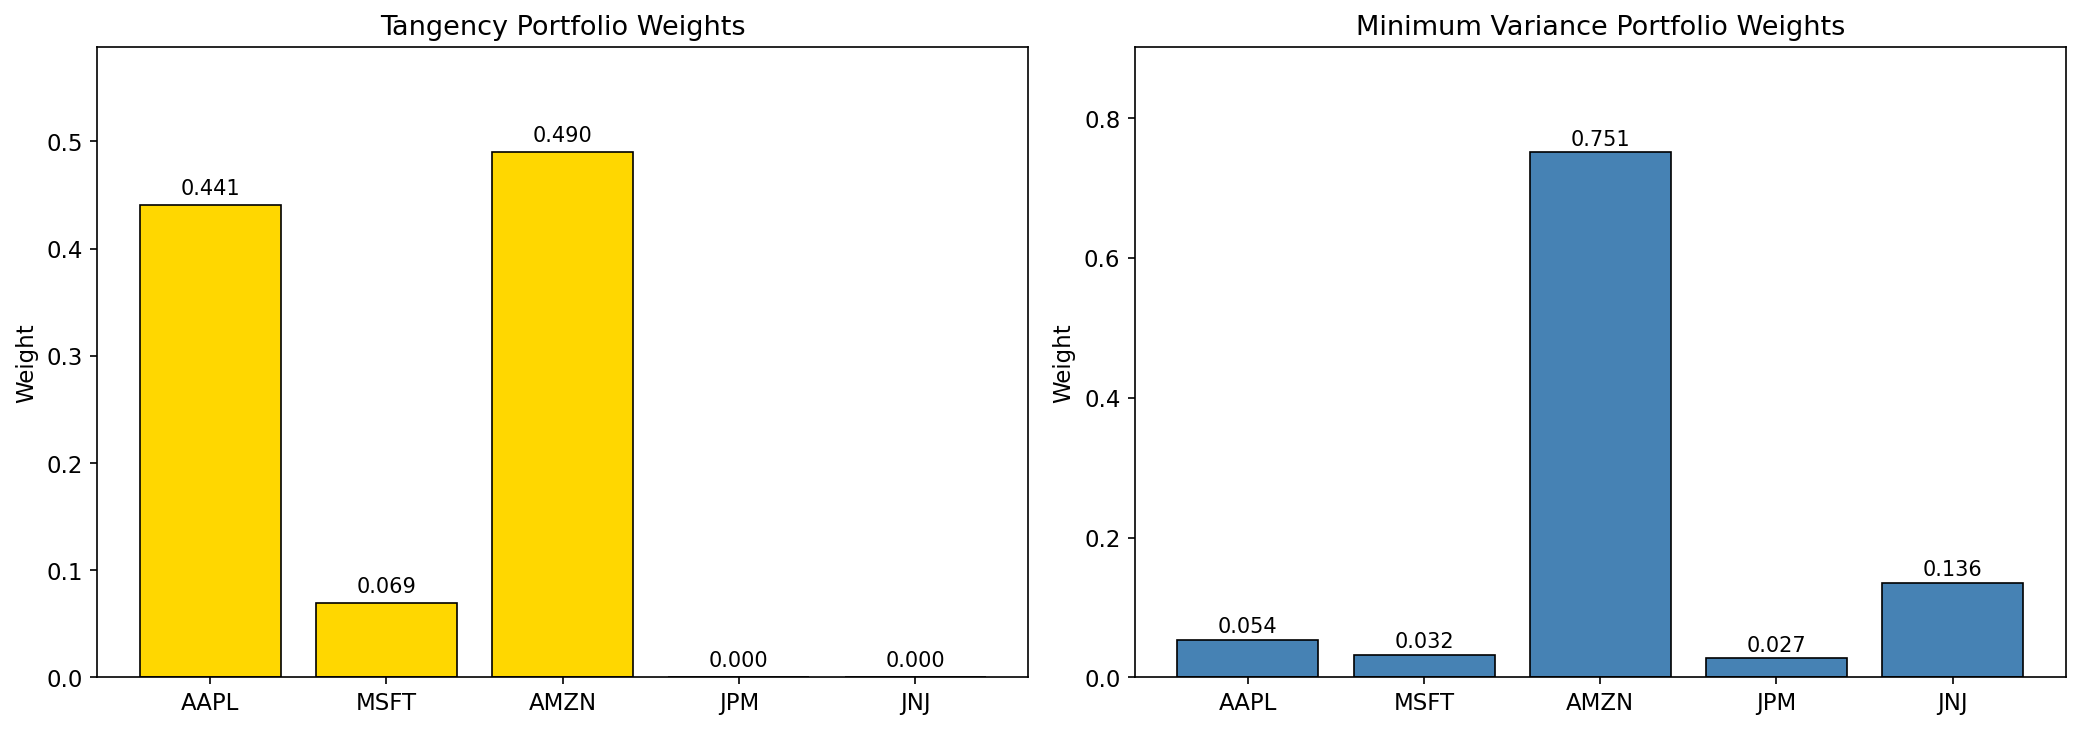

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 接線ポートフォリオ
axes[0].bar(tickers, tangency_weights, color='gold', edgecolor='black', linewidth=0.8)
axes[0].set_title('Tangency Portfolio Weights', fontsize=13)
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, max(tangency_weights) * 1.2)
for i, v in enumerate(tangency_weights):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# 最小分散ポートフォリオ
axes[1].bar(tickers, gmvp_weights, color='steelblue', edgecolor='black', linewidth=0.8)
axes[1].set_title('Minimum Variance Portfolio Weights', fontsize=13)
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, max(gmvp_weights) * 1.2)
for i, v in enumerate(gmvp_weights):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()